### 5kb下Embedding & Gene expression prediction

In [2]:
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm, trange

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import preprocessing
from scipy.stats import pearsonr, spearmanr 
from scipy.special import comb, perm
import re

from genomic_regions import as_region

plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [3]:
## total bin pos -- node id
hg38_node2bin = pd.read_table('/data/xujs/Project/DeepLearning/MCIP/Results/preprocess_results/hg38.5kb.node2bin.txt', header=None, names=['node_id', 'chrom_pos'])
hg38_node2bin['node_id'] = hg38_node2bin['node_id'] - 1

In [4]:
df_hg38_5kb = pd.read_table('/data/xujs/References/human/hg38/hg38_windows/hg38.window_5kb.bed', names=['chrom', 'start', 'end', 'name'])
df_hg38_5kb.head()

,chrom,start,end,name
0,chr1,0,5000,chr1_0-5000
1,chr1,5000,10000,chr1_5000-10000
2,chr1,10000,15000,chr1_10000-15000
3,chr1,15000,20000,chr1_15000-20000
4,chr1,20000,25000,chr1_20000-25000


In [5]:
## GM12878 Gene expression.
rna_seq_file = '/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/RNA-seq/GM12878.RNA-seq.hg38.ENCFF563OCX.5kb_bigWigAverageOverBed_Averagesignal.bed'

# The file columns are:
#    name - name field from bed, which should be unique
#    size - size of bed (sum of exon sizes
#    covered - # bases within exons covered by bigWig
#    sum - sum of values over all bases covered
#    mean0 - average over bases with non-covered bases counting as zeroes
#    mean - average over just covered bases

df_rna_seq = pd.read_table(rna_seq_file, header=None, names=['name', 'size', 'covered', 'sum', 'mean0', 'mean'])
# df_rna_seq = df_repli_seq.loc[df_repli_seq.score != 0]
# df_rna_seq['chrom_pos'] = df_repli_seq['chrom'] + ":" + df_repli_seq['start'].astype(str)
df_rna_seq['scale_exp'] = preprocessing.scale(df_rna_seq['mean'])
df_rna_seq['log_exp'] = (df_rna_seq['mean'] + 1).apply(np.log2)
df_rna_seq.head()

,name,size,covered,sum,mean0,mean,scale_exp,log_exp
0,chr1_0-5000,5000,5000,0.00,0.00000,0.00000,-0.015396,0.000000
1,chr1_5000-10000,5000,5000,0.00,0.00000,0.00000,-0.015396,0.000000
2,chr1_10000-15000,5000,5000,7344.17,1.46883,1.46883,0.009643,1.303827
3,chr1_15000-20000,5000,5000,62807.00,12.56140,12.56140,0.198732,3.761434
4,chr1_20000-25000,5000,5000,53310.90,10.66220,10.66220,0.166357,3.543768


In [6]:
df_hg38_5kb_gene = pd.read_table('/data/xujs/References/human/hg38/hg38.gene.bed', header=None,
                                    names=['chrom', 'start', 'end', 'gene', 'len', 'strand'])

name_list = []
bin_size = 5000
for idx, row in df_hg38_5kb_gene.iterrows():
    chrom, start, end, gene, gene_len = row['chrom'], int(row['start']), int(row['end']), row['gene'], int(row['len'])
    start_ = int((start + gene_len/2)/bin_size)*bin_size
    name = f'{chrom}_{start_}-{start_+bin_size}'
    name_list.append(name)

df_hg38_5kb_gene['name'] = name_list

df_hg38_5kb_gene = df_hg38_5kb_gene[['name', 'gene']]

df_hg38_5kb_gene.head()

,name,gene
0,chr1_65000-70000,OR4F5
1,chr1_450000-455000,OR4F29
2,chr1_685000-690000,OR4F16
3,chr1_930000-935000,SAMD11
4,chr1_950000-955000,NOC2L


In [7]:
df_hg38_5kb_rna_seq = pd.merge(df_hg38_5kb, df_rna_seq)
df_hg38_5kb_rna_seq.head()

,chrom,start,end,name,size,covered,sum,mean0,mean,scale_exp,log_exp
0,chr1,0,5000,chr1_0-5000,5000,5000,0.00,0.00000,0.00000,-0.015396,0.000000
1,chr1,5000,10000,chr1_5000-10000,5000,5000,0.00,0.00000,0.00000,-0.015396,0.000000
2,chr1,10000,15000,chr1_10000-15000,5000,5000,7344.17,1.46883,1.46883,0.009643,1.303827
3,chr1,15000,20000,chr1_15000-20000,5000,5000,62807.00,12.56140,12.56140,0.198732,3.761434
4,chr1,20000,25000,chr1_20000-25000,5000,5000,53310.90,10.66220,10.66220,0.166357,3.543768


In [8]:
df = pd.merge(df_hg38_5kb_rna_seq, df_hg38_5kb_gene, on='name', how='left')
df.head()

,chrom,start,end,name,size,covered,sum,mean0,mean,scale_exp,log_exp,gene
0,chr1,0,5000,chr1_0-5000,5000,5000,0.00,0.00000,0.00000,-0.015396,0.000000,NaN
1,chr1,5000,10000,chr1_5000-10000,5000,5000,0.00,0.00000,0.00000,-0.015396,0.000000,NaN
2,chr1,10000,15000,chr1_10000-15000,5000,5000,7344.17,1.46883,1.46883,0.009643,1.303827,NaN
3,chr1,15000,20000,chr1_15000-20000,5000,5000,62807.00,12.56140,12.56140,0.198732,3.761434,NaN
4,chr1,20000,25000,chr1_20000-25000,5000,5000,53310.90,10.66220,10.66220,0.166357,3.543768,NaN


In [10]:
### GAE Embedding
 
import torch

chrom_region_dict = np.load(f'/data/xujs/Project/HiC2PoreC/code/H2P/dataset/hg38.5kb.chrom_region_dict.npy', allow_pickle=True).item()
embs = {}
for chrom in chrom_region_dict:
    for chrom_region in chrom_region_dict[chrom]:
        emb = torch.load(f'/data/xujs/Project/HiC2PoreC/code/H2P/Emb/HiPore-C_GM12878_5kb/{chrom}/{chrom_region}_64.pt', map_location=torch.device('cpu')).detach().numpy()
        embs[chrom_region] = emb

np.save('./GAE_embeddings.npy', embs)

embs = np.load('./GAE_embeddings.npy', allow_pickle=True).item()

In [11]:
def convert_chrom_region(region):
    chrom, start, end = re.split(':|-|_', region)
    return f'{chrom}:{start}-{end}'

name_list = []
emb_list = []

for chrom_region, chrom_region_emb in embs.items():
    chrom_region_ = as_region(convert_chrom_region(chrom_region))
    chrom_region_range = np.arange(chrom_region_.start, chrom_region_.end, bin_size).tolist() + [chrom_region_.end]
    for i in range(len(chrom_region_range) - 1):
        start, end = chrom_region_range[i], chrom_region_range[i+1]
        name = f'{chrom_region_.chromosome}_{start}-{end}'
        name_list.append(name)
    emb_list.append(chrom_region_emb)

emb_list = np.concatenate(emb_list)

df_emb = pd.concat([pd.DataFrame({'name': name_list}),
                    pd.DataFrame(emb_list)], axis=1)

In [12]:
df = pd.merge(df, df_emb)
    
df_onlyGene = df.dropna()
df_onlyGene = df_onlyGene.loc[df_onlyGene['mean'] != 0]

In [16]:
# 划分训练集和测试集

train_chroms = ['chr1', 'chr3', 'chr5', 'chr7', 'chr9', 'chr11', 'chr13', 'chr15', 'chr17', 'chr19', 'chr21', 'chrX']
test_chroms = ['chr2', 'chr4', 'chr6', 'chr8', 'chr10', 'chr12', 'chr14', 'chr16', 'chr18', 'chr22']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# print(X_train.shape, X_test.shape)

X_train, y_train = np.array(df_onlyGene.loc[df_onlyGene.chrom.isin(train_chroms), 0:]),  np.array(df_onlyGene.loc[df_onlyGene.chrom.isin(train_chroms), 'scale_exp'])
X_test, y_test =  np.array(df_onlyGene.loc[df_onlyGene.chrom.isin(test_chroms), 0:]), np.array(df_onlyGene.loc[df_onlyGene.chrom.isin(test_chroms), 'scale_exp'])
print(X_train.shape, X_test.shape)

(8949, 64) (5888, 64)


In [17]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train.ravel())
y_pred_rf = rf.predict(X_test)

mae_rf = sklearn.metrics.mean_absolute_error(y_test, y_pred_rf)
mse_rf = sklearn.metrics.mean_squared_error(y_test, y_pred_rf)
r2_rf = sklearn.metrics.r2_score(y_test, y_pred_rf)
spearman_r = round(spearmanr(y_test, y_pred_rf)[0], 2)

evaluations_rf_df = pd.DataFrame({
    'Model': ['RF'],
    'MAE': [mae_rf],
    'MSE': [mse_rf],
    'R2': [r2_rf],
    'Spearman_R': [spearman_r],
})

print(evaluations_rf_df)

  Model       MAE        MSE       R2  Spearman_R
0    RF  0.425723  53.318928 -0.00335        0.08


In [32]:
df = pd.DataFrame({
    "y_test": y_test,
    "y_pred_rf": y_pred_rf
})

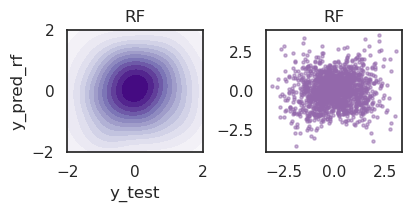

In [33]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(4, 2), constrained_layout=True)
axes = axes.flatten()

sns.kdeplot(x=df['y_test'], y=df['y_pred_rf'], cmap='Purples', cbar=False, fill=True, thresh=0.0, n_levels=15, bw_adjust=1.5, bw_method='scott', cumulative=False, ax=axes[0])
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)

axes[1].scatter(x=df['y_test'], y=df['y_pred_rf'], alpha=0.5, s=5, c='#9368ab')
# axes[1].set_xlim(-2, 2)
# axes[1].set_ylim(-2, 2)

axes[0].set_title('RF')
axes[1].set_title('RF')
# axes[0].legend_.remove()

# for i in range(5):
#     axes[i].set_xlim(-1, 1)
#     axes[i].set_ylim(-1, 1)

fig.savefig('./predict_Gene_Expression_results/Gene_expression.GAE_Embedding.scatter_plot.pdf')

In [118]:
# pd.DataFrame({'y_true': y_test, 'y_pred_rf': y_pred_rf}).to_csv('./predict_Gene_Expression_results/rf.pred_gene_expression_result.txt', sep='\t', index=False, header=True)